# Obtaining the cutouts of the plates

In [1]:
import json
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import random
import base64
import gzip
import requests
import os

##

In [2]:
index = {}

with open("../Step_2_Integration/observability_bright.json", "rb") as f:
    while True:
        pos = f.tell()
        line = f.readline()

        if not line:
            break

        s = line.strip()

        if s in (b"", b"{", b"}"):
            continue

        # key is before first colon
        key_bytes = s.split(b":", 1)[0]
        key = json.loads(key_bytes.decode())

        index[int(key)] = pos

print("nkeys:", len(index))

def load_observability_key(filename, index, key):
    key = int(key)

    with open(filename, "rb") as f:
        f.seek(index[key])
        line = f.readline().decode().strip()

    if line.endswith(","):
        line = line[:-1]

    rec = json.loads("{" + line + "}")
    data = np.asarray(rec[str(key)])
    return data

nkeys: 54355


In [3]:
from tqdm import tqdm

In [4]:
mpc_nums = np.sort(list(index.keys()))
photometric_summary = []
for num in tqdm(mpc_nums, desc="Processing MPCs"):
    data = load_observability_key("../Step_2_Integration/observability_bright.json", index, num)
    ra,dec,rearth,rsun,dradt,ddecdt,jd,platid,vmag = data.T
    vmag = vmag.astype(float)
    photometric_summary.append([num,len(vmag),np.mean(vmag),np.median(vmag),np.std(vmag)])
photometric_summary = np.array(photometric_summary)

Processing MPCs: 100%|███████████████████| 54355/54355 [03:25<00:00, 264.42it/s]


In [5]:
np.save("photometric_summary.npy", photometric_summary)

## Now do some plotting

In [6]:
photometric_summary

array([[1.00000000e+00, 6.26300000e+03, 7.13002749e+00, 7.09265584e+00,
        4.63822573e-01],
       [2.00000000e+00, 6.62800000e+03, 8.29645658e+00, 8.54226367e+00,
        8.46092840e-01],
       [3.00000000e+00, 6.37100000e+03, 8.91275695e+00, 9.06234003e+00,
        9.39019168e-01],
       ...,
       [6.20105000e+05, 2.00000000e+01, 1.69210386e+01, 1.69825948e+01,
        2.97040952e-01],
       [6.20106000e+05, 1.30000000e+01, 1.66312121e+01, 1.66665636e+01,
        3.27351553e-01],
       [6.20107000e+05, 4.50000000e+01, 1.58863262e+01, 1.59478226e+01,
        9.65887104e-01]])

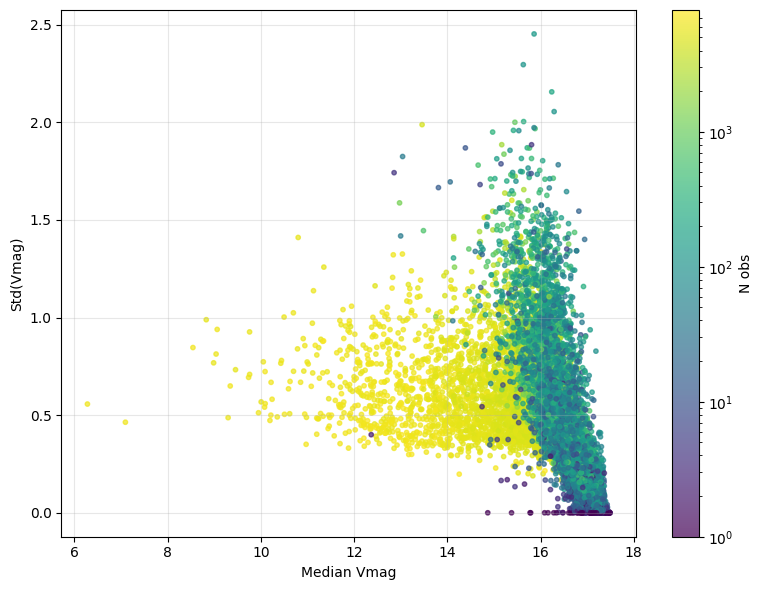

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

nobs = photometric_summary[:,1]
median = photometric_summary[:,3]
std = photometric_summary[:,4]

plt.figure(figsize=(8,6))

sc = plt.scatter(median, std, c=nobs, cmap="viridis", norm=LogNorm(), s=10, alpha=0.7)

plt.colorbar(sc, label="N obs")
plt.xlabel("Median Vmag")
plt.ylabel("Std(Vmag)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

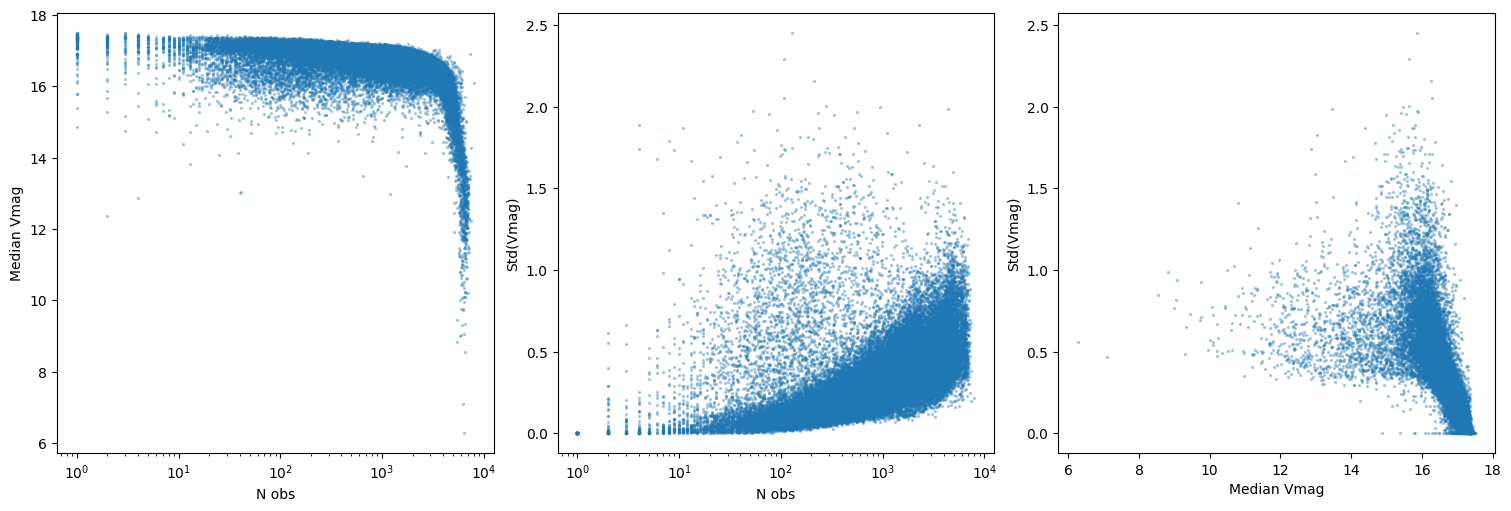

In [9]:
import matplotlib.pyplot as plt

nobs = photometric_summary[:,1]
median = photometric_summary[:,3]
std = photometric_summary[:,4]

fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

ax[0].scatter(nobs, median, s=2, alpha=0.3, rasterized=True)
ax[0].set_xlabel("N obs")
ax[0].set_ylabel("Median Vmag")
ax[0].set_xscale("log")

ax[1].scatter(nobs, std, s=2, alpha=0.3, rasterized=True)
ax[1].set_xlabel("N obs")
ax[1].set_ylabel("Std(Vmag)")
ax[1].set_xscale("log")

ax[2].scatter(median, std, s=2, alpha=0.3, rasterized=True)
ax[2].set_xlabel("Median Vmag")
ax[2].set_ylabel("Std(Vmag)")

plt.show()

In [11]:
targets = np.arange(6, 21)

for mag in targets:
    mask = photometric_summary[:,1] >= 1000
    rows = photometric_summary[mask]

    score = ((rows[:,3] - mag)/0.25)**2 + (rows[:,4]/0.05)**2

    best = rows[np.argmin(score)]

    print(
        f"{mag:2d}: MPC {int(best[0]):7d} "
        f"median={best[3]:.3f} "
        f"std={best[4]:.4f} "
        f"nobs={int(best[1])}"
    )

 6: MPC       1 median=7.093 std=0.4638 nobs=6263
 7: MPC       1 median=7.093 std=0.4638 nobs=6263
 8: MPC       1 median=7.093 std=0.4638 nobs=6263
 9: MPC      29 median=9.297 std=0.4871 nobs=6195
10: MPC     196 median=10.971 std=0.3507 nobs=6720
11: MPC     196 median=10.971 std=0.3507 nobs=6720
12: MPC     702 median=11.881 std=0.3313 nobs=6504
13: MPC     420 median=13.172 std=0.2983 nobs=6947
14: MPC     624 median=14.256 std=0.1979 nobs=7463
15: MPC    1437 median=15.039 std=0.2292 nobs=6740
16: MPC   15440 median=16.436 std=0.1688 nobs=5657
17: MPC   15136 median=17.158 std=0.0696 nobs=1329
18: MPC   10886 median=17.186 std=0.0740 nobs=1047
19: MPC   10886 median=17.186 std=0.0740 nobs=1047
20: MPC   10886 median=17.186 std=0.0740 nobs=1047


In [12]:
mpc_ids = [1, 29, 196, 702, 420, 624, 1437, 15440, 15136, 10886]